# AP 155 Lab Exercise
---
## Exercise 2: Numbers in Computers

_Instructions_: 
- **Report figure (Problem 1):** Answer and follow the (Modified) Gezerlis 2.6
- **Report figure (Problem 2):** Answer and follow the (Modified) Gezerlis 2.8

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina
- _Student No._: 2024-092224
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)

![Loss of precision in the 'bad' x+ formula](rel_error-x.png)

**Figure 1**. Loss of precision in the 'bad' $x_+$ formula

The quadratic equation was solved using both the standard quadratic formula and a numerically stable alternative. Using \(a=c=1\) and varying $b$, the standard formula can experience catastrophic cancellation when calculating the smaller root because it involves subtracting two nearly equal quantities.

The figure presents the relative error of the standard formula as the magnitude of $b$ increases for 32-bit and 64-bit floating-point precision. The 32-bit calculation begins to lose accuracy at smaller values of $b$, while the 64-bit calculation maintains greater accuracy and only shows significant error at larger values of $b$. This illustrates how increased floating-point precision reduces the effects of numerical cancellation and why the stable formula $x_+ = c/(ax_-)$ is preferred when computing the smaller root for large $b$.

### Problem 2: Singularity (Gezerlis 2.8)

### Part 1

![Figure 2](figure1_singularity1.png)

**Figure 2:** Graph of the function

![Figure 3](figure1_singularity2.png)

**Figure 3:** Direct computation vs. trig-identity computation of f(x).

For $f(x)=\frac{1-\cos x}{x^2}$, the figure illustrates the numerical instability caused by subtracting two nearly equal values as $x$ approaches zero. Although the true limit is $0.5$, the direct computation loses accuracy at around $1.5\times10^{-7}$ for `float64`, whereas the trigonometric identity avoids this cancellation and remains close to $0.5$, making it the more reliable formulation.


![Figure 5](bonusd.png)

**Figure 4:** Direct Computation at Different Floating-Point Precisions

The figure compares the direct computation using 16-, 32-, 64-, and 128-bit floating-point precision. The 16-bit computation becomes unstable earlier, while the higher-precision computations remain closer to the expected limit of $0.5$, showing that greater precision can reduce the effects of numerical instability.

![Figure 4](bonust.png)

**Figure 5:** Trigometric Identity Plot at Different Floating-Point Precisions

The figure shows that the trigonometric identity remains close to the expected value of $0.5$ for most precisions, with the 16-bit computation showing noticeable instability only at very small $x$. This demonstrates that reformulating the expression reduces the effects of catastrophic cancellation and improves numerical stability.


![Figure 6](figure2_manual_numpy.png) 


**Figure 6:** Manual evaluation vs Numpy's special function

For $f(x)=\frac{e^x-1}{x}$, numerical errors become significant as \(x\) gets closer to zero because the direct calculation involves subtracting two nearly equal values. The manual computation approaches zero for $x\lesssim10^{-14}$, while `expm1(x)` maintains values close to the expected limit of $1$, demonstrating its improved numerical stability.


### Other comments
- N/A


---
## Section 2: Code

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)

Take the standard quadratic equation: $ax^2 + bx + c = 0$, whose solutions are 

$$x_{\pm}=\frac{-b \pm \sqrt{b^2-4ac}}{2a}$$

Take $b>0$ for concreteness. It is easy to see that when $b^2 >> ac$, we don't get a catastrophic cancellation when evaluating $b^2 - 4ac$ (we may still get a "benign" cancellation). Furthermore, $\sqrt{b^2-4ac} \approx b$. 

However, this means that $x_+$ will involve catastrophic cancellation in the numerator. We will employ an analytical trick in order to help us preserve significant figures. Observe that the product of the two roots must obey 

$$x_+ x_- = \frac{c}{a}$$

The answer now presents itself: use the standard quadratic formula to calculate $x_-$, for which no catastrophic cancellation takes place. Then, use $x_+ x_- = \frac{c}{a}$ to calculate $x_+$. Notice that you end up calculating $x_+$, via division only (i.e. without a catastrophic cancellation). 

Write a Python code (use `np.sqrt()`) that evaluates and prints out **(a)** $x_-$, **(b)** $x_+$ using the "bad formula", and **(c)** $x_+$ using the "good formula". 

Take $a=1$, $c=1$, $b=10^8$. Discuss the answers.

Lastly, **(d)** [FIGURE] Visualize the loss of precision by plotting the relative error of the "bad" $x_+$ formula. Vary $b$ using a log scaling (e.g., from $10^4$ to $10^9$). To highlight the effect of hardware limits, evaluate the bad formula using both 32-bit (np.float32) and 64-bit (np.float64) precision, comparing them against the "good" formula as the baseline.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

In [79]:
#---Constants--
a = 1
b = 1e8
c = 1

# Calculates discriminants for brevity
def calculate_disc(a,b,c):
    disc = b**2 - 4*a*c
    if disc < 0:
        return False
    return disc

# Calculates the negative root 
def neg_root(a,b,c):
    disc_sqr = np.sqrt(calculate_disc(a, b, c))
    m_root = -(b + disc_sqr) / (2*a)
    return m_root

# Calculates the positive root that causes catastrophic cancellation
def bad_pos_root(a,b,c):
    disc_sqr = np.sqrt(calculate_disc(a, b, c))
    bad_p_root = -(b - disc_sqr) / (2*a)
    return bad_p_root

# Calculates the positive root with no subtraction of nearly equal numbers
def good_pos_root(a,b,c):
    disc_sqr = np.sqrt(calculate_disc(a, b, c))
    good_p_root = c / (a*neg_root(a, b ,c))
    return good_p_root

if calculate_disc(a,b,c) != False: # Checks whether the discriminant is non negative
    item_1 = neg_root(a,b,c)
    item_2 = bad_pos_root(a,b,c)
    item_3 = good_pos_root(a,b,c)
    difference = abs(item_2 - item_3)
    err = abs(difference / item_3)
    print(f"negative root: {item_1}\nbad positive root: {item_2} \ngood positive root: {item_3} \n \n difference (positive root): {difference}\n error (relative to good positive root): {err*100}%")
else:
    print("No real solutions.")

negative root: -100000000.0
bad positive root: -7.450580596923828e-09 
good positive root: -1e-08 
 
 difference (positive root): 2.549419403076172e-09
 error (relative to good positive root): 25.49419403076172%


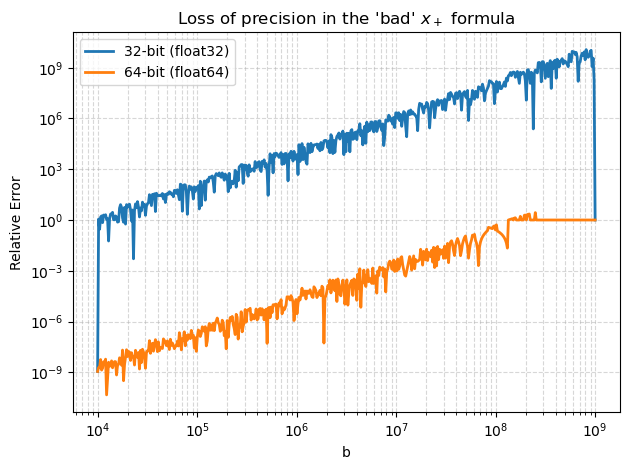

In [123]:
# Visualizing the loss of precision by plotting the relative error of bad positive root
b_values = np.logspace(4, 9, 500)

# Create an empty list to store relative errors 
error_float32 = []
error_float64 = []

for b in b_values:
    # --- 32-bit Precision --- 
    # Converts b values into 32-bit floating-point precision
    a32 = np.float32(1.0)
    b32 = np.float32(b)
    c32 = np.float32(1.0)

    disc32 = b32**2 -np.float32(4.0)*a32*c32 # Calculates the discriminant using 32-bit floating-point numbers
    sqrt_disc32 = np.sqrt(np.abs(disc32))

    x_bad32 = (-b + sqrt_disc32) / (np.float32(2.0)*a32)
    x_neg32 = (-b - sqrt_disc32) / (np.float32(2.0)*a32)
    x_good32 = c32 / (a32*x_neg32)

    rel_error32 = abs((x_bad32 - x_good32) / x_good32)
    error_float32.append(rel_error32)

    # --- 64-bit Precision ---
    # Converts b values into 64-bit floating-point precision
    a64 = np.float64(1.0)
    b64 = np.float64(b)
    c64 = np.float64(1.0)

    disc64 = b64**2 - np.float64(4.0)*a64*c64 # Calculates the discriminant using 64-bit floating-point numbers
    sqrt_disc64 = np.sqrt(np.abs(disc64))

    x_bad64 = (-b + sqrt_disc64) / (np.float64(2.0)*a64)
    x_neg64 = (-b - sqrt_disc64) / (np.float64(2.0)*a64)
    x_good64 = c64 / (a64*x_neg64)

    rel_error64 = abs((x_bad64 - x_good64) / x_good64)
    error_float64.append(rel_error64)

# Create the plot
plt.figure()

# Makes the plot use logarithmic scales with different b values for the horizontal axis and 32-bit relative error for the vertical axis
plt.loglog(b_values, error_float32, label = "32-bit (float32)", linewidth = 2)

# Makes the plot use logarithmic scales with different b values for the horizontal axis and 64-bit relative error for the vertical axis
plt.loglog(b_values, error_float64, label = "64-bit (float64)", linewidth = 2)

plt.xlabel("b")
plt.ylabel("Relative Error")
plt.title("Loss of precision in the 'bad' $x_+$ formula")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### Problem 1 code summary

This code evaluates the roots of a quadratic equation and demonstrates how catastrophic cancellation can cause a loss of precision. The negative root $x_-$ is calculated using the standard quadratic formula, while the positive root $x_+$ is computed using two approaches: direct substitution into the quadratic formula and the product-of-roots property for a more numerically stable result. To further illustrate the effects of catastrophic cancellation, the relative error of the unstable formula is compared using 32-bit and 64-bit floating-point precision as the value of $b$ increases.

### Problem 2: Singularity (Gezerlis 2.8)

#### Part 1:

We will study the following function:

$$f(x) = \frac{1-\cos x}{x^2}$$

**(a)** Start by plotting the function, with a step size of $0.1$ from $x=0.1$ to $x=10$. This should give you some idea of the values you should expect for $f(x)$ at small $x$. You can do this by using `np.arange()` to generate a `numpy array` that you will feed to a function that you will define.

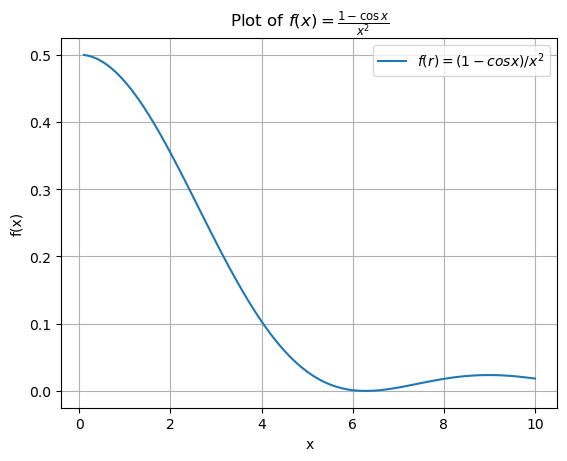

In [82]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (1-np.cos(x)) / x**2

# Generate x-values from 0.1 to 10 with a step size of 0.1
x = np.arange(0.1, 10.1, 0.1)

# Calculate the corresponding y-values
y = f(x)

# Plot the function
plt.figure()
plt.plot(x, y, label=r'$f(r)=(1-cos x)/x^2$')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Plot of $f(x) = \frac{1-\cos x}{x^2}$")
plt.grid(True)
plt.legend()
plt.show()

**(b)** Verify your previous hunch by taking the limit as $x \longrightarrow 0$ and using L'Hopital's rule. You will submit this at the end of the class on a piece of paper.

**(c)** Now, see what value you find for $f(x)$ when $x=1.2 \times 10^{-8}$. Does this make sense qualitatively?

**(d)** Use a trigonometric identity to avoid the cancellation. Evaluate the new function at $x=1.2 \times 10^{-8}$ and compare with your analytical answer for $x \longrightarrow 0$.

In [85]:
x_small = 1.2e-8
result = f(x_small)
print("x =", x_small)
print("f(x) =", result)
print("Expected limit is", 0.5)

# Rewrite f(x) using the trigonometric identity 1 - cos(x) = 2sin^2(x/2)
def f_identity(x):
    return (2*np.sin(x/2)**2) / x**2

result_identity = f_identity(x_small)
print("f(x) using trigonometric identity =", result_identity)

x = 1.2e-08
f(x) = 0.7709882115452477
Expected limit is 0.5
f(x) using trigonometric identity = 0.5


**(e)** [FIGURE] Produce a figure that compares fow $f(x)$ approaches a certain value as $x \longrightarrow 0$, between directly computing $f(x)$ and by using a trigonometric identity to "avoid the cancellation". 

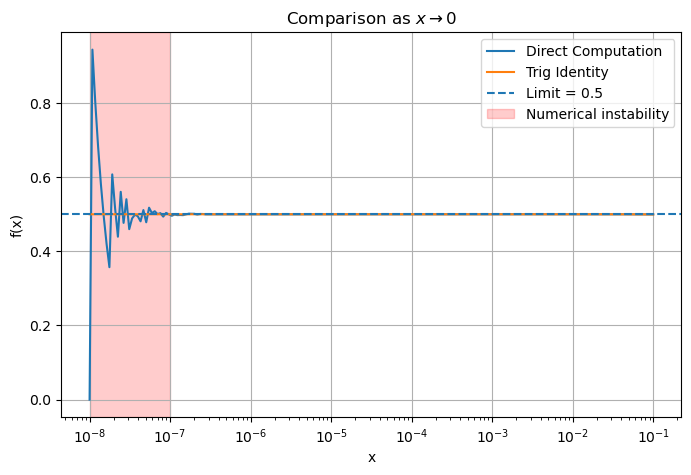

In [97]:
# Creates 200 x-values spaced logarithmically from 10^-1 to 10^-8
x_values = np.logspace(-1, -8, 200)

y_direct = f(x_values) # Calculate f(x) using the original expression
y_identity = f_identity(x_values) # Calculate f(x) using the equivalent trigonometric identity

plt.figure(figsize=(8,5))

# Plot both functions using a logarithmic scale on the x-axis
plt.semilogx(x_values, y_direct, label="Direct Computation")
plt.semilogx(x_values, y_identity, label="Trig Identity")

plt.axhline(0.5, linestyle="--", label="Limit = 0.5")
plt.axvspan(1e-8, 1e-7, alpha=0.2, color='red', label="Numerical instability")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Comparison as $x \rightarrow 0$')
plt.grid(True)
plt.legend()
plt.show()

**Bonus**: also compare part with different hardware floating-point precisions: 16/32/64/128-bit. 

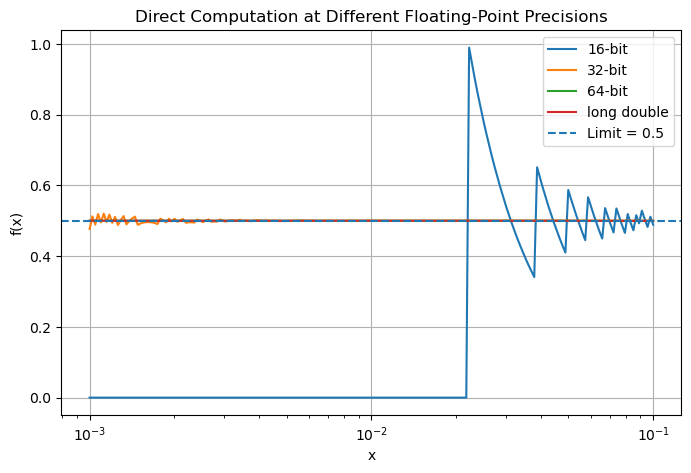

In [122]:
# Bonus: Direct Computation

def f(x):
    return (1-np.cos(x)) / x**2

# Generate x-values
x_values = np.logspace(-1, -3, 200) # 16-bit becomes unstable around 10^-2 to 10^-1

# Floating-point precisions
precisions = [np.float16, np.float32, np.float64, np.longdouble]

# Store results for each precisions
results = {}

# Calculate f(x) using each precision
for dtype in precisions:
    x_precision = x_values.astype(dtype) # Converts all the x_values into different precisions in the list
    results[dtype] = f(x_precision)

# Plot

plt.figure(figsize=(8, 5))
plt.semilogx(x_values, results[np.float16], label="16-bit")
plt.semilogx(x_values, results[np.float32], label="32-bit")
plt.semilogx(x_values, results[np.float64], label="64-bit")
plt.semilogx(x_values, results[np.longdouble], label="long double")

# Expected analytical limit
plt.axhline(0.5, linestyle="--", label="Limit = 0.5")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Direct Computation at Different Floating-Point Precisions")
plt.grid(True)
plt.legend()
plt.show()


The direct computation starts close to 0 for larger values of $x$, but becomes increasingly unstable around $10^{-2}$ as $x$ decreases, eventually approaching the expected value of 0.5. In comparison, the trigonometric identity avoids the subtraction causing catastrophic cancellation, with the 32-bit, 64-bit, and 128-bit computations remaining close to 0.5, while the 16-bit computation becomes unstable at very small values of $x$.

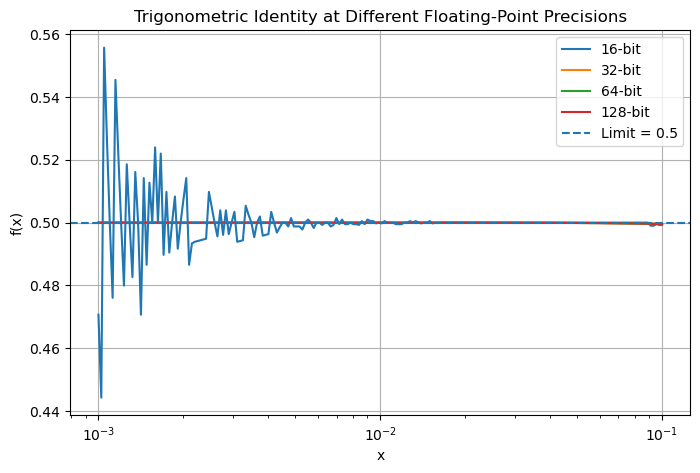

In [112]:
# Bonus: Trigonometric identity

def f_identity(x):
    return (2*np.sin(x/2)**2) / x**2


# Generate x-values
x_values = np.logspace(-1, -3, 200)

# Floating-point precisions
precisions = [np.float16, np.float32, np.float64, np.longdouble]

# Store results for each precisions
results = {}

# Calculate f(x) using each precision
for dtype in precisions:
    x_precision = x_values.astype(dtype) # Converts all the x_values into different precisions in the list
    results[dtype] = f_identity(x_precision)

# Plot

plt.figure(figsize=(8, 5))
plt.semilogx(x_values, results[np.float16], label="16-bit")
plt.semilogx(x_values, results[np.float32], label="32-bit")
plt.semilogx(x_values, results[np.float64], label="64-bit")
plt.semilogx(x_values, results[np.longdouble], label="128-bit")

# Expected analytical limit
plt.axhline(0.5, linestyle="--", label="Limit = 0.5")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Trigonometric Identity at Different Floating-Point Precisions")
plt.grid(True)
plt.legend()
plt.show()

The graph shows that the 16-bit computation becomes noticeably unstable around $10^{-3}$ to $10^{-2}$, while the 32-bit, 64-bit, and 128-bit computations remain very close to the expected value of 0.5. This shows that the trigonometric identity reduces catastrophic cancellation and produces a more numerically stable computation, especially at higher floating-point precisions.

#### Part 2:

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

**(a)** For which values of x does the catastrophic cancellation occur?

Catastrophic cancellation occurs when the $x$ is very small, particularly as $x$ approaches $0$. As $x\to0$, $e^x$ becomes very close to $1$, so calculating $e^x -1$ involves subtracting two nearly equal numbers. This can cause a loss if significant digits and lead to numerical inaccuracy. 

(b) How can we resolve the catastrophic cancellation?

To avoid catastrophic cancellation, we can use NumPy's `expm1(x)` function, which is designed to calculate $e^x - 1$ accurately and avoid this problem.

(c) [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

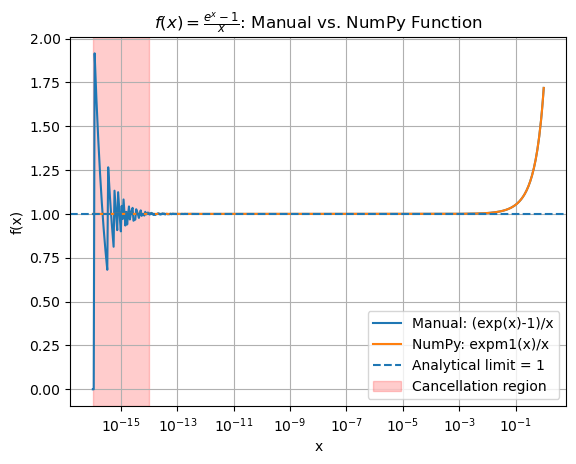

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Computes the expression manually
def f_manual(x):
    return (np.exp(x) - 1) / x

# Computes the expression using NumPy's special function
def f_numpy(x):
    return (np.expm1(x)) / x

n = np.logspace(-16, 0, 500)

# Calculates the y-values
y_numpy = f_numpy(n)
y_manual = f_manual(n)

plt.figure()

plt.semilogx(n, y_manual, label="Manual: (exp(x)-1)/x")
plt.semilogx(n, y_numpy, label="NumPy: expm1(x)/x")

plt.axhline(1, linestyle="--", label="Analytical limit = 1")
plt.axvspan(1e-16, 1e-14, alpha=0.2, label="Cancellation region", color='red')

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title(r"$f(x) = \frac{e^x-1}{x}$: Manual vs. NumPy Function")
plt.legend()
plt.grid(True)
plt.savefig('man-numpy.png')
plt.show()

#### Problem 2 code summary

The code investigates catastrophic cancellation in two functions, $\frac{1-cosx}{x^2}$ and $\frac{e^x - 1}{x}$, by comparing their direct computations with numerically stable equivalent methods, such as using trigonometric substitution $1-\cos(x) = 2\sin^2\left(\frac{x}{2}\right)$ and NumPy's special function `expm1`, as $x$ approaches zero. The results are plotted across several orders of magnitude and compared with their analytical limits, allowing the program to demonstrate how reformulating a computation can reduce loss of precision and improve numerical stability.

---
## Section 3: Background

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

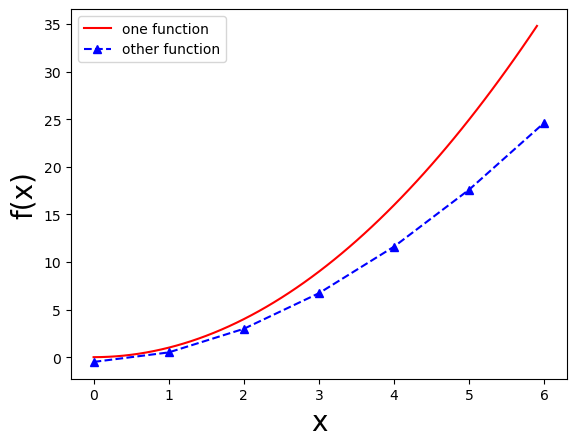

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

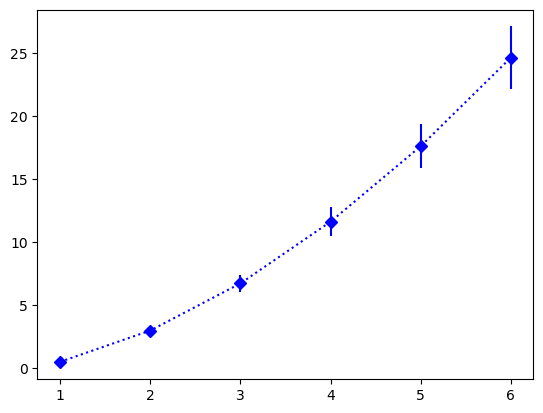

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])